# NOTEBOOK 1: Using Simple Models to Learn About Streamflow Generation

### Importing Some Python Packages/Libraries...Don't worry about these

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

RAW = "../data/raw"

### Running Some Code to Get us started...Don't worry about these

In [2]:
import sys
sys.path.append("../scripts")
from nb01_helpers_v_2 import water_year, fit_mlr, plot_climatology_comparison, plot_precip_temp_vs_flow, run_mlr_activity, plot_mlr_results

In [3]:
"""
precipitation --> monthly, NCEI
temperature --> monthly, NCEI
soil moisture --> monthly, NOAH (SB) & PFCLM (UCRB)
temperature (SNOTEL) --> monthly, USDA
"""

WY_START, WY_END = 1981, 2019

################
##### UCRB #####
p = pd.read_csv(f"{RAW}/ncei_precip_monthly_v_2.csv", parse_dates=["Date"])
t = pd.read_csv(f"{RAW}/ncei_temp_monthly_v_2.csv", parse_dates=["Date"])
sm = pd.read_csv(f"{RAW}/ucrb_baseline_storage_v_2.csv", index_col=0, parse_dates=True)
flow = pd.read_csv(f"{RAW}/naturalized_flow_leesferry_monthly_v_2.csv", parse_dates=["date"])

p["ym"] = p["Date"].dt.to_period("M")
t["ym"] = t["Date"].dt.to_period("M")
sm["ym"] = sm.index.to_period("M")
flow["ym"] = flow["date"].dt.to_period("M")

ucrb = (
    p[["ym", "precip_cm"]]
    .merge(t[["ym", "temp_degC"]], on="ym")
    .merge(sm[["ym", "SM_storage[cm]"]], on="ym")
    .merge(flow[["ym", "acre_feet"]], on="ym")
)
ucrb["date"] = ucrb["ym"].dt.to_timestamp()
ucrb["wy"] = ucrb["date"].apply(water_year)
ucrb = ucrb[(ucrb["wy"] >= WY_START) & (ucrb["wy"] <= WY_END)]

ucrb["precip_in"] = ucrb["precip_cm"] / 2.54
ucrb["temp_F"] = ucrb["temp_degC"] * 9 / 5 + 32
ucrb["sm_anom_cm"] = ucrb["SM_storage[cm]"] - ucrb["SM_storage[cm]"].mean()
ucrb["flow_af"] = ucrb["acre_feet"]

ucrb_df = ucrb.set_index("date")[["precip_in", "temp_F", "sm_anom_cm", "flow_af"]]

##### UCRB #####
################

################
##### Stony Brook #####
sb_pt = pd.read_csv(f"{RAW}/stonybrook_precip_temp_monthly_v_2.csv")
sb_sm = pd.read_csv(f"{RAW}/stonybrook_soilmoisture_monthly_v_2.csv")
sb_flow = pd.read_csv(f"{RAW}/stonybrook_streamflow_monthly_v_2.csv", parse_dates=["date"])

sb = sb_pt.merge(sb_sm[["year", "month", "soilm_basin_avg"]], on=["year", "month"])
sb["date"] = pd.to_datetime(sb[["year", "month"]].assign(day=1))
sb = sb.merge(sb_flow, on="date")

sb["wy"] = sb["date"].apply(water_year)
sb = sb[(sb["wy"] >= WY_START) & (sb["wy"] <= WY_END)]

sb["precip_in"] = sb["precip_basin_avg_mm"] / 25.4
sb["temp_F"] = sb["temp_basin_avg_C"] * 9 / 5 + 32
sb["sm_cm"] = sb["soilm_basin_avg"] / 10
sb["sm_anom_cm"] = sb["sm_cm"] - sb["sm_cm"].mean()

stonybrook_df = sb.set_index("date")[["precip_in", "temp_F", "sm_anom_cm", "flow_af"]]

##### Stony Brook #####
################

################
##### UCRB SNOTEL #####
# "Representative" high-elevation UCRB SNOTEL station (Red Mountain Pass, ~11,100 ft),
snotel_temp = pd.read_csv(f"{RAW}/snotel_representative_temp_monthly_climatology_v_2.csv")
snotel_temp = snotel_temp.set_index("month")["air_temp_F"]
# snotel_temp.head()

snotel_precip = pd.read_csv(f"{RAW}/snotel_representative_precip_monthly_climatology_v_2.csv")
snotel_precip = snotel_precip.set_index("month")["precip_in"]
# snotel_precip.head()
##### UCRB SNOTEL #####
################

### Printing Some "Dataframes" (python version of spreadsheet data) to get us kicked off
#### **precip_in** = precipitation [inches]
#### **temp_F** = temperature [deg F]
#### **sm_anom_cm** = soil moisture anomaly (departure from average) [cm]
#### **flow_af** = streamflow at watershed outlet [acre-feet]

In [4]:
"""
Just making sure that things look ok. We should have severa dataframes with dates in the left column and climate variables
in the other columns. 
"""
print("**Stony Brook Dataframe**")
display(stonybrook_df.head(10))
print("\n**UCRB Dataframe**")
display(ucrb_df.head(10))
# print("**UCRB SNOTEL TEMP**")
# display(snotel_temp.head())

# print(ucrb_df.shape, stonybrook_df.shape)
# ucrb_df.describe()

**Stony Brook Dataframe**


,precip_in,temp_F,sm_anom_cm,flow_af
date,,,,
1980-10-01,4.001671,52.238794,-14.365595,703.735511
1980-11-01,3.060288,40.847070,-9.094593,1097.652851
1980-12-01,0.591536,29.660132,-4.972260,426.842959
1981-01-01,0.500541,22.905518,-4.693354,197.752059
1981-02-01,4.188929,36.284009,-0.267951,5640.396483
1981-03-01,1.368846,38.160254,2.182012,2209.586694
1981-04-01,3.888338,53.100122,2.365783,4066.115550
1981-05-01,5.152468,60.647290,3.689898,4468.760163
1981-06-01,4.237892,69.930078,0.903374,796.165259



**UCRB Dataframe**


,precip_in,temp_F,sm_anom_cm,flow_af
date,,,,
1980-10-01,1.401575,45.266,-0.398637,353235.0
1980-11-01,0.674409,34.538,0.246759,414120.0
1980-12-01,0.522835,33.332,0.576002,414830.0
1981-01-01,0.435039,30.596,0.390929,331854.0
1981-02-01,0.562992,30.722,0.391620,320685.0
1981-03-01,1.973622,35.276,1.326758,403149.0
1981-04-01,0.924803,46.886,2.361087,680365.0
1981-05-01,2.415354,50.900,3.147905,1244135.0
1981-06-01,0.615354,63.932,1.970119,2309668.0


## **ACTIVITY: Let the data speak for themselves!** What does an average year look like in each of these watersheds?

In [5]:
"""
Dataframes were daily. Now, we are changing them from daily to MONTHLY averages (T) or totals (P). 
We will plot these below. 
"""
stonybrook_df_monthly = stonybrook_df.groupby(stonybrook_df.index.month).mean()
ucrb_df_monthly = ucrb_df.groupby(ucrb_df.index.month).mean()

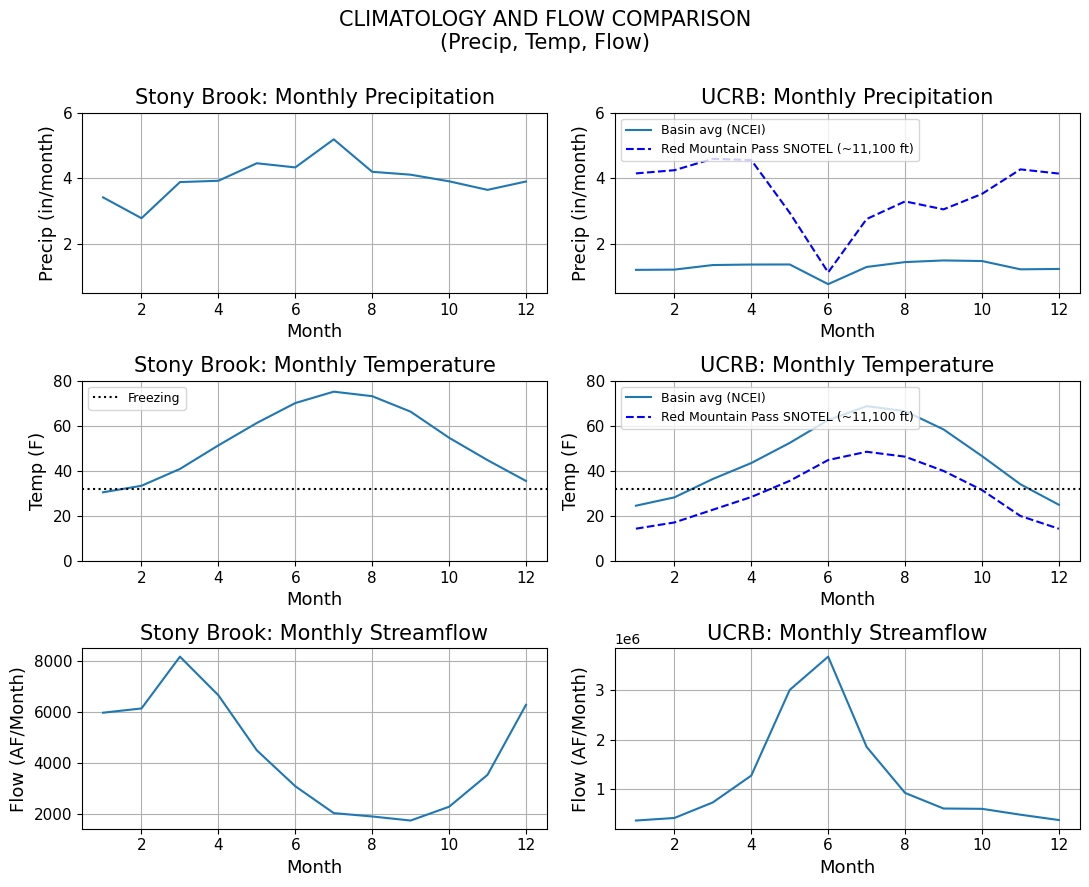

In [6]:
plot_climatology_comparison(stonybrook_df_monthly, ucrb_df_monthly, snotel_temp, snotel_precip)

### **Discuss** and prepare to share your observations with the class:
#### - Describe any patterns you see in the temperature and precipitation within each basin. How are they similar/different? 
#### - Describe any patterns you see in the flow for each basin.
#### - Can you hypothesize about any (potential) relationships between P, T, and flow in either basin? 
#### - Why do you think we included the SNOTEL precipitation and temperature timeseries for the UCRB? 
#### - What else did you notice? Did this make you wonder anything? Do you have any new questions about the data (or about the watersheds) now that you have seen it? 

#
### **Linear Regression Modeling** --> What are the relationships between our climate characteristics and streamflow? 
#### Run the plotting cell below. 

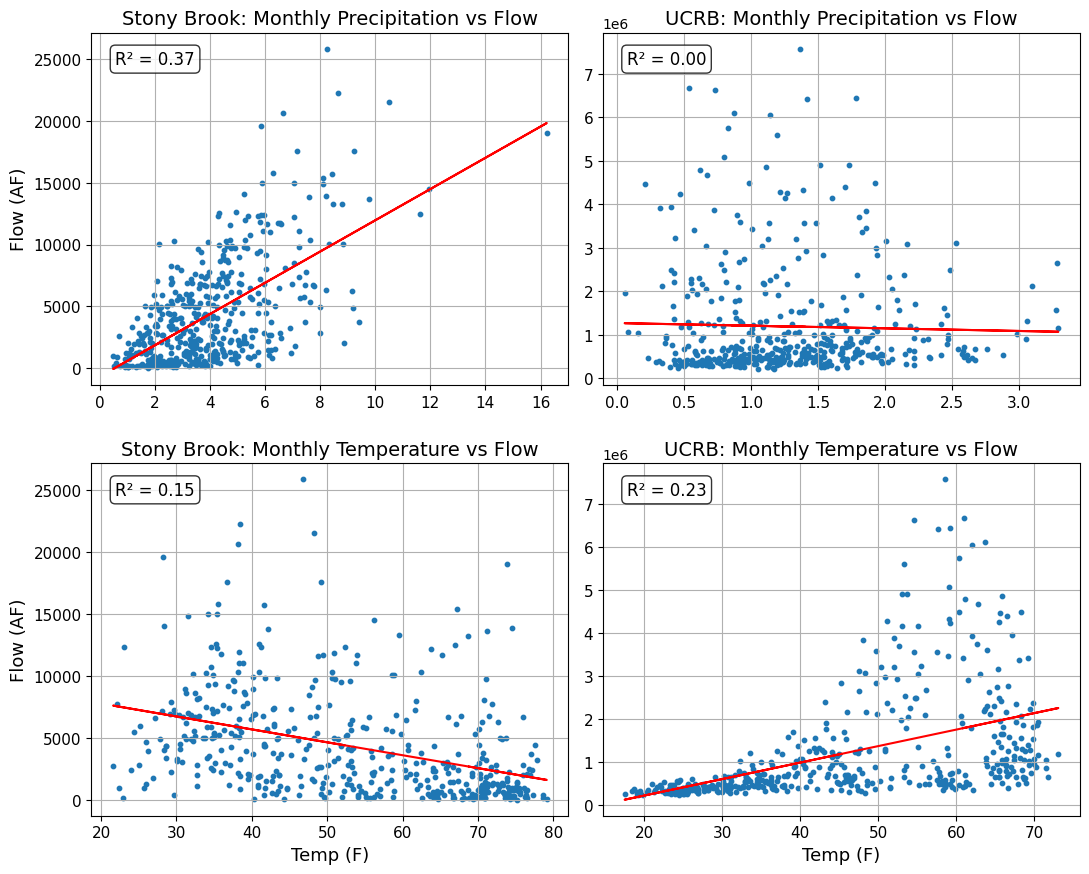

In [7]:
plot_precip_temp_vs_flow(stonybrook_df, ucrb_df)

### **Discuss** and prepare to share your observations with the class:
#### - How would you assess the relationship between temperature and precipitation with streamflow in each basin? 
#### - In UCRB, flow looks like it is higher during months with high temperatures -- why might *warmer* months mean *more* flow in this basin?
#### - In the Stony Brook, increasing temperature seems to lead to lower streamflow (the opposite of the UCRB). What mechanism might be responsible for this? Consider the water balance (0 = P - ET - Q). Which of those variables might be most directly affected by temperature here in our temperate forest climate of central Jersey?)
#### - What could be missing from this single-variable approach?

# ------------------------------------------------------------------------------------
# ------------------------------------------------------------------------------------

## **Activity: The Sword in the Stony Brook** 

### Here, we are going to build a **multiple linear regression (MLR) model** of the Stony Brook watershed. You will have three predictor variables to choose from (precipitation, temperature, and soil moisture). MLR models work similarly to (simple) linear regression models in that they try to fit a (now 2D/3D/4D/...) "line" that minimizes error between predictions and observed data. The MLR algorithm uses some fancy* mathematics to consider all the possible relationships between the variables to figure out the best set of relationships between the predictor variables (e.g. T) and the response variable (e.g. streamflow). Remember that MLR models are able to consider how certain variables relate to each other. For example, a MLR model with T and P is not the same as a simple linear regression of T **+** a simple linear regression of P. The relationship between P and flow would be different between a simple model and a model with T also included. 
### **YOUR QUEST:**
#### 1. First, try each variable individually. We can start with precipitation (P) together. You can do this by setting **USE_P = True** and keep the other predictors (USE_T, USE_SM) set to = False. Try the same thing with T and then SM. 
#### 2. After you try predictors indiviually, you can see how combining predictors helps improve your model. If you set USE_P and USE_T to true, you can look at how the model improves by including temperature and precipitation together. 
##### - **Do you see any improvement considering both together? What led you to your conclusion?**
#### 3. If you have extra time, you can also see if the hydrologic system posesses hydrologic memory. What on earth does this mean? This means that in some systems, events in the past influence current conditions. For example, it may rain a lot one day without flooding. If it rains again a few days later, there might be lots of flooding! There's no difference in the amount of rain, but the system has changed states based on a previous event and this changed state can influence how the system responds to a similar perturbation.  For help, read the "extre credit" text in the cell below to learn about how to incorporate memory into the MLR model. Basically, we are just adding another predictor variable....just one that is temporally ofset by however much you specify. Jot down and ideas and observations!
##### - **Can you think of an example of hydrologic memory, inside or outside of the stony brook? When or where might previous hydrologic conditions influence current hydrologic conditions?** 
##### - **Do you see any evidence of noticeable hydrologic memory in Stony Brook?**

#### 4. What would have helped us remove the sword more easily? 
##### - **If you could add another variable to examine, what would it be?**
##### - **Can you predict/sketch what you expect its seasonal timeseries might look like?**
##### - **Why would it help your prediction?** 

###### * *some of my professors would use the word "trivial" here but alas I have a different relationship with linear algebra than they do*

In [ ]:
# --- toggle predictors and their lags (in months; 0 = same month as flow) ---
"""
START BY CHANGING THESE ONE-BY-ONE, THEN TOGETHER...
"""
USE_P = True
USE_T = False
USE_SM = False

"""
For ~extra credit~, you can modify the lags to test the memory of this watershed. 
[0]      --> The Default. Means "only consider predictor month x to flow in month x"
[0,1, #] --> Consider lag. Means "consider predictor month x (0), x-1 (1), and x-# (#) to flow in month x. 
             FOR EXAMPLE: If P_LAGS set to 2, we tell our model to consider P for the current month, and two prior months. 
             If we wanted to predict flow in July of a given year, the model would be allowed to consider precipitation in July as well as the precipitation in the preceeding June and May. 
"""
P_LAGS = [0] # remember USE_P must also be set to 'True' for this to work! 
T_LAGS = [0]# remember USE_T must also be set to 'True' for this to work! 
SM_LAGS = [0]# remember USE_SM must also be set to 'True' for this to work! 

#### Can ignore the code here. This is just doing some legwork to help us get our answers. 

In [13]:
X, y, activity_data, beta, r2_activity, y_pred = run_mlr_activity(
    stonybrook_df, USE_P, USE_T, USE_SM, P_LAGS, T_LAGS, SM_LAGS
)
# print(f"n = {len(y)}, R² = {r2_activity:.2f}")

### PLOTTED RESULTS -- TAKE NOTE! 

/home/nj1079/PhD_Research/QUEST_2026/Start_Here/notebooks/../scripts/nb01_helpers_v_2.py:311: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


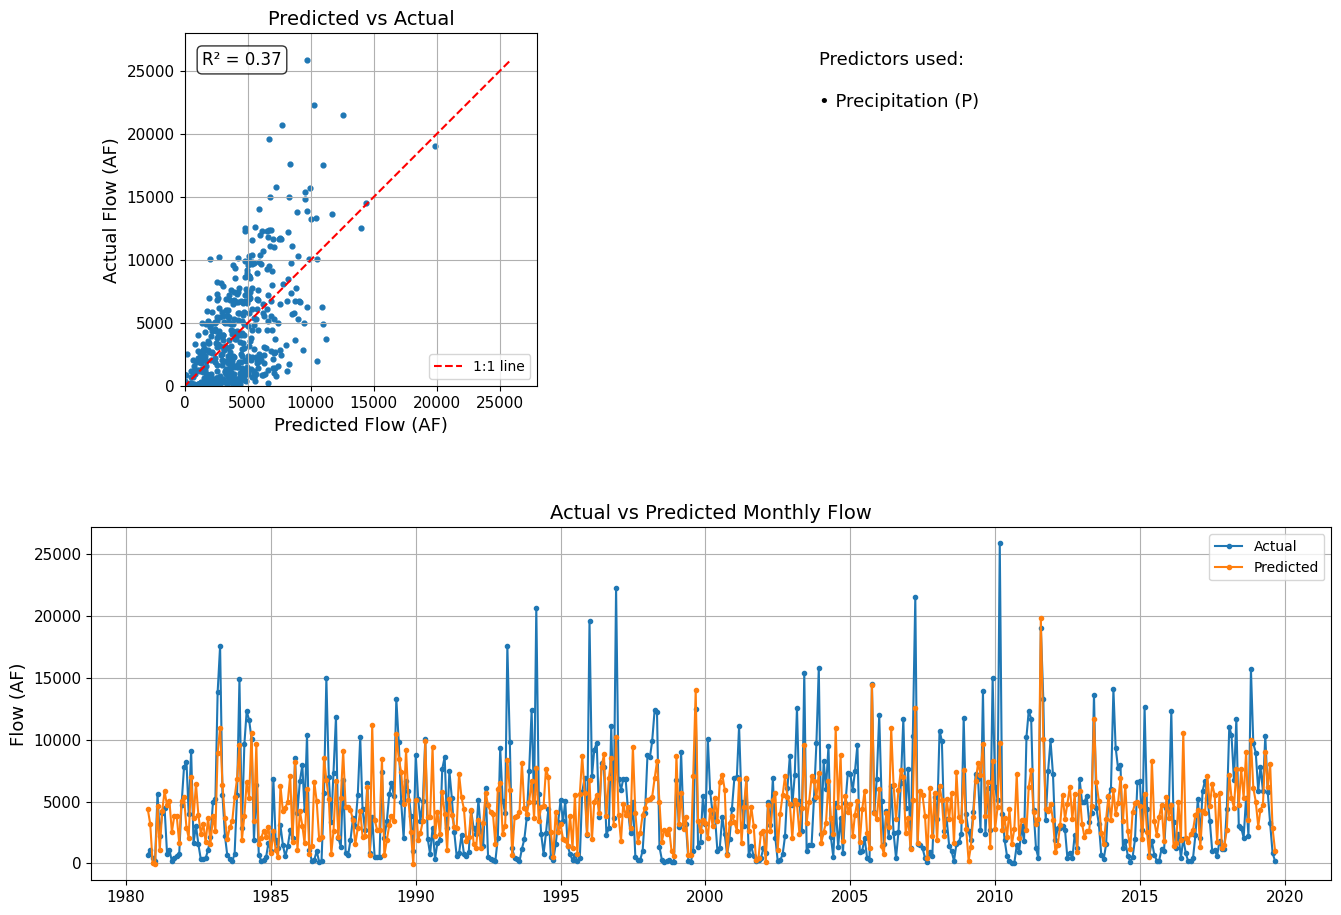

In [14]:
plot_mlr_results(X, activity_data, y, y_pred, r2_activity)

#### If we have time, introduce this concept to gauge relative importance of each predictor... 

In [11]:
# fig, ax = plt.subplots(figsize=(8, 5))
# ax.bar(X.columns, beta)
# ax.axhline(0, color="black", linewidth=0.8)
# ax.set_ylabel("Standardized coefficient (beta weight)", fontsize=13)
# ax.set_title(f"Which factors matter most? (R² = {r2_activity:.2f})", fontsize=14)
# ax.tick_params(labelsize=11, axis="x", rotation=30)
# ax.tick_params(labelsize=11, axis="y")
# ax.grid(axis="y")
# plt.tight_layout()
# plt.show()